[資料來源](https://insideairbnb.com/get-the-data/)  
[維基百科](https://en.wikipedia.org/wiki/Inside_Airbnb)

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
import re
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance    
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans, HDBSCAN
import jieba
import nltk
from nltk.corpus import stopwords
from umap import UMAP
import pickle
from nltk.corpus import stopwords
import string

In [104]:
data = pd.read_csv('airbnb_reviewers.csv')

In [105]:
data.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,68398,2894700,2012-11-16,3534183,Laura,I enjoyed my stay very much! Spend approx 6 we...
1,68398,13416072,2014-05-27,12750484,Maggie,I ended up staying in Studio B. Apartment is c...
2,68398,22427468,2014-11-06,21131563,Vincent,"Lisa est très efficace, le logement est foncti..."
3,68398,48514756,2015-09-27,31102107,Romney,I arrived a little early but Vincent valiantly...
4,68398,58001272,2015-12-31,44450239,Sheila,Our host made us feel very welcomed and was al...


In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197304 entries, 0 to 197303
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     197304 non-null  int64 
 1   id             197304 non-null  int64 
 2   date           197304 non-null  object
 3   reviewer_id    197304 non-null  int64 
 4   reviewer_name  197303 non-null  object
 5   comments       197254 non-null  object
dtypes: int64(3), object(3)
memory usage: 9.0+ MB


In [107]:
data.dropna(subset=['reviewer_name', 'comments'], inplace=True)

In [108]:
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

In [109]:
data['Year'] = data['date'].dt.year
data['Month'] = data['date'].dt.month
data['Day'] = data['date'].dt.day

In [110]:
data = data.drop(columns=['date', 'listing_id', 'id', 'reviewer_name'])

In [111]:
data

,reviewer_id,comments,Year,Month,Day
0,3534183,I enjoyed my stay very much! Spend approx 6 we...,2012,11,16
1,12750484,I ended up staying in Studio B. Apartment is c...,2014,5,27
2,21131563,"Lisa est très efficace, le logement est foncti...",2014,11,6
3,31102107,I arrived a little early but Vincent valiantly...,2015,9,27
4,44450239,Our host made us feel very welcomed and was al...,2015,12,31
...,...,...,...,...,...
197299,538654660,Would definitely recommend this place! Thank y...,2024,12,28
197300,560328455,Séjour parfait!,2024,12,31
197301,124555341,房間也相當乾淨整潔，服務人員都很親切，有問題都會即時回應，非常棒的住宿體驗👍🏽<br/>Ho...,2024,12,26
197302,188994001,"The apartment looked exactly like the photos, ...",2024,12,27


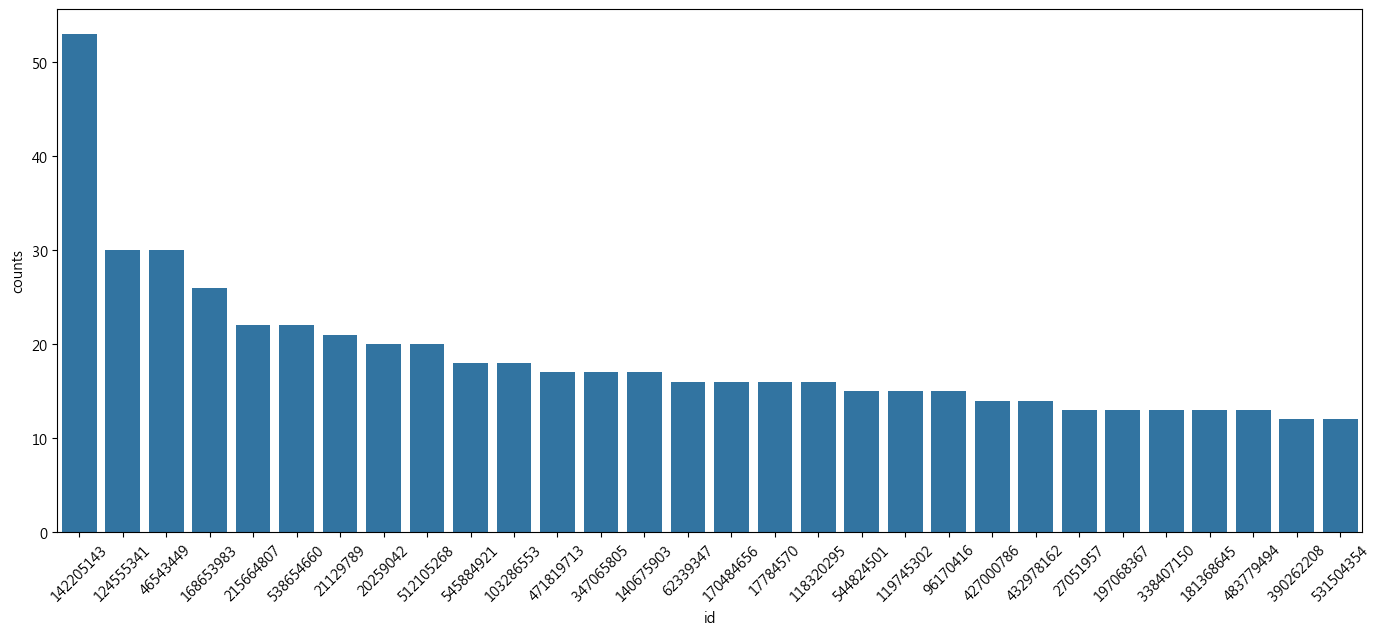

In [112]:
id_counts = data['reviewer_id'].value_counts().reset_index()
id_counts.columns = ['id', 'counts']
top30_id_counts = id_counts.head(30)
top30_id_counts['id'] = pd.Categorical(top30_id_counts['id'], 
                                       categories=top30_id_counts['id'], 
                                       ordered=True)
plt.figure(figsize=(14, 6))
sns.barplot(data=top30_id_counts.head(30), x='id', y='counts')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

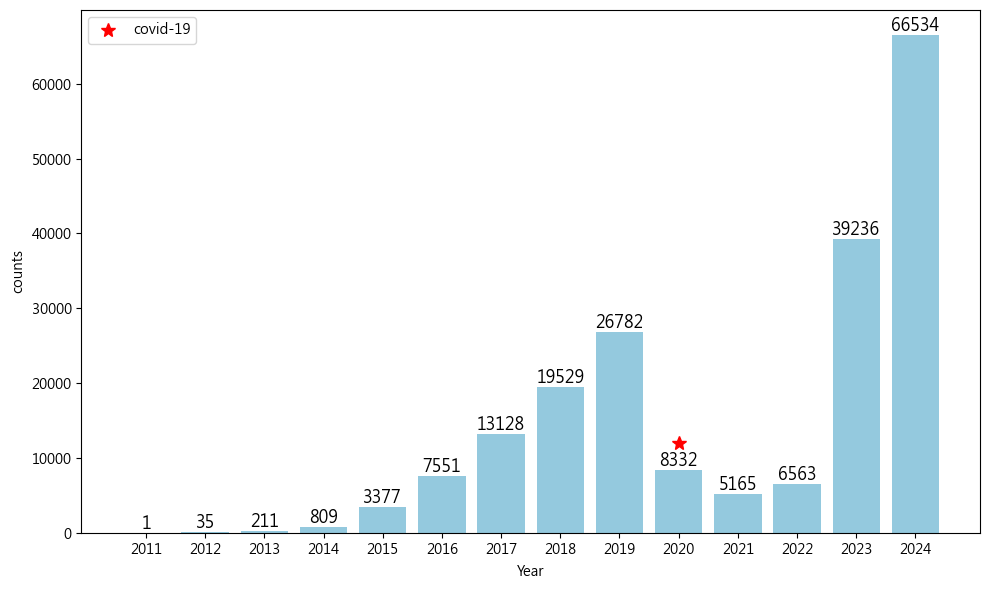

In [113]:
year_counts = data['Year'].value_counts().sort_index().reset_index()
year_counts.columns = ['Year', 'counts']

year_counts['Year'] = year_counts['Year'].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=year_counts, x='Year', y='counts', color='skyblue')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
    
year_index = year_counts[year_counts['Year'] == '2020'].index[0]
ax.plot(year_index, 12000, "*", markersize=10, color="r", label="covid-19")

plt.legend()    
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


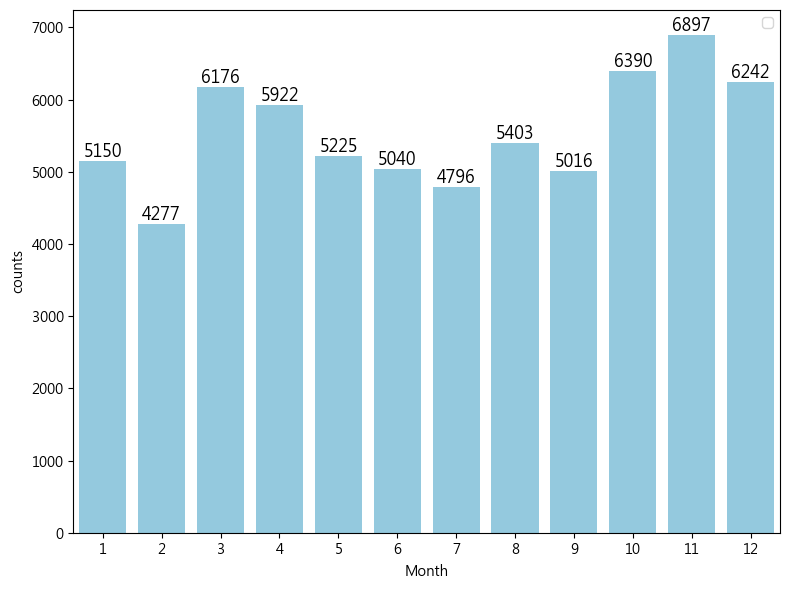

In [114]:
data2024 = data[data['Year']==2024]
                 
month_counts = data2024['Month'].value_counts().sort_index().reset_index()
month_counts.columns = ['Month', 'counts']

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=month_counts, x='Month', y='counts', color='skyblue')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.legend()    
plt.tight_layout()
plt.show()

In [115]:
context = data['comments']
context

0         I enjoyed my stay very much! Spend approx 6 we...
1         I ended up staying in Studio B. Apartment is c...
2         Lisa est très efficace, le logement est foncti...
3         I arrived a little early but Vincent valiantly...
4         Our host made us feel very welcomed and was al...
                                ...                        
197299    Would definitely recommend this place! Thank y...
197300                                      Séjour parfait!
197301    房間也相當乾淨整潔，服務人員都很親切，有問題都會即時回應，非常棒的住宿體驗👍🏽<br/>Ho...
197302    The apartment looked exactly like the photos, ...
197303    非常棒附近也非常便利<br/>宵夜也非常多<br/>離捷運站也非常近 交通非常方便<br/>...
Name: comments, Length: 197253, dtype: object

In [116]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text)                               # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text)                 # 刪網址
    text = re.sub(r'<.*?>+', '', text)                                # 刪 HTML tag
    text = re.sub(r'\n', ' ', text)                                   # 換行→空白
    text = re.sub(r'\w*\d\w*', ' ', text)                             # 含數字詞
    text = re.sub(r'\d+', ' ', text)                                  # 數字
    text = re.sub(r'\s+', ' ', text).strip()                          # 連續空白
    return text
data["cleaned_comments"] = data["comments"].apply(clean_text)
data.head()

,reviewer_id,comments,Year,Month,Day,cleaned_comments
0,3534183,I enjoyed my stay very much! Spend approx 6 we...,2012,11,16,i enjoyed my stay very much spend approx weeks...
1,12750484,I ended up staying in Studio B. Apartment is c...,2014,5,27,i ended up staying in studio b apartment is co...
2,21131563,"Lisa est très efficace, le logement est foncti...",2014,11,6,lisa est très efficace le logement est fonctio...
3,31102107,I arrived a little early but Vincent valiantly...,2015,9,27,i arrived a little early but vincent valiantly...
4,44450239,Our host made us feel very welcomed and was al...,2015,12,31,our host made us feel very welcomed and was al...


In [117]:
data['cleaned_comments'][27]

'住了一晚女生四人房，虽然小了点，但是很干净，公用洗手间也是非常非常干净，这点让第一次住青旅的我简直无可挑剔。当天晚上和一个韩国妹子一个房间，两个母语不是英语的人居然聊到了凌晨，好开心哦。总之推荐这家住宿啦！'

In [118]:
from opencc import OpenCC

cc = OpenCC('s2t')  # s2t: simplified to traditional

def convert_to_traditional(text: str) -> str:
    return cc.convert(text)

data['converted_comments'] = data['comments'].apply(clean_text).apply(convert_to_traditional)


In [119]:
data['converted_comments'][27]

'住了一晚女生四人房，雖然小了點，但是很乾淨，公用洗手間也是非常非常乾淨，這點讓第一次住青旅的我簡直無可挑剔。當天晚上和一個韓國妹子一個房間，兩個母語不是英語的人居然聊到了凌晨，好開心哦。總之推薦這家住宿啦！'

In [138]:
docs_2024 = data[data['Year']==2024].reset_index(drop=True)['converted_comments'].tolist()

In [139]:
sentence_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
embeddings = sentence_model.encode(docs_2024, show_progress_bar=True)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom')

representation_model = MaximalMarginalRelevance(diversity=0.2)
vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(embedding_model=sentence_model,
                        vectorizer_model=vectorizer_model,
                        calculate_probabilities=True,
                        umap_model=umap_model,
                        hdbscan_model=hdbscan_model,
                        representation_model=representation_model,
                        verbose=True)

Topics, Probs = topic_model.fit_transform(docs_2024, embeddings)

Batches:   0%|          | 0/2080 [00:00<?, ?it/s]

2025-05-19 01:58:24,093 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-19 01:59:17,462 - BERTopic - Dimensionality - Completed ✓
2025-05-19 01:59:17,463 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-19 01:59:47,841 - BERTopic - Cluster - Completed ✓
2025-05-19 01:59:47,858 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-19 02:01:12,955 - BERTopic - Representation - Completed ✓


In [144]:
topic_model.get_topic_freq().head(15)

,Topic,Count
0,-1,35761
82,0,2770
20,1,2205
28,2,2080
8,3,603
14,4,597
61,5,537
35,6,449
29,7,416
16,8,408


In [145]:
topic_model.visualize_barchart(top_n_topics=15)

In [125]:
summer_new_topics = summer_topic_model.reduce_outliers(summerDocs, summerTopics, strategy="embeddings", embeddings=summerembeddings)


In [126]:
summer_topic_model.update_topics(summerDocs, topics=summer_new_topics, vectorizer_model=vectorizer_model)

2025-05-19 00:55:43,610 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [127]:
summer_topic_model.reduce_topics(summerDocs, nr_topics=15)

2025-05-19 00:55:52,034 - BERTopic - Topic reduction - Reducing number of topics
2025-05-19 00:55:52,092 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-19 00:55:52,351 - BERTopic - Representation - Completed ✓
2025-05-19 00:55:52,354 - BERTopic - Topic reduction - Reduced number of topics from 104 to 15


In [129]:
summer_topic_model.get_topic_freq()

,Topic,Count
0,0,7750
2,1,4334
3,2,1097
4,3,930
5,4,514
11,5,110
1,6,100
8,7,99
13,8,70
6,9,68


In [130]:
summer_topic_model.visualize_barchart(top_n_topics=5)


In [82]:
# new_topics, new_probs = topic_model.transform(docs)
# assert topics == new_topics
# topic_model.save("my_model")
# my_model = BERTopic.load("my_model")
# new_topics, new_probs = my_model.transform(docs)
# pickle.dump(topics, open( "topics.pickle", "wb" ) )
# assert topics == new_topics

---

In [ ]:
Taipei_list = pd.read_csv('airbnb_listings(2).csv')
Taipei_list.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,68398,Tonghua Studio C near MRT & Taipei 101,339014,Lisa,NaN,大安區,25.028775,121.554686,Entire home/apt,NaN,30,12,2024-11-05,0.08,5,280,2,NaN
1,271733,Taipei Rooftop - Whole apartment!,242033,Robyn And David,NaN,文山區,25.005810,121.555180,Entire home/apt,1350.0,14,72,2024-11-25,0.46,1,25,4,NaN
2,272314,"Long Stay Welcome, Taipei 101 Building is here",1425203,Chen,NaN,大安區,25.042240,121.542650,Entire home/apt,1312.0,90,9,2014-12-31,0.06,1,358,0,NaN
3,289296,Fabulous studio - Center Taipei (Monthly),1338052,Herman,NaN,大安區,25.042870,121.551120,Entire home/apt,2822.0,30,29,2024-04-23,0.24,2,341,1,NaN
4,289298,Fabulous Studio in heart of Taipei,1338052,Herman,NaN,中山區,25.080910,121.559020,Entire home/apt,2362.0,30,188,2024-11-12,1.33,2,341,1,NaN


### Airbnb 房源資料欄位說明（Inside Airbnb - Taipei）

| 欄位名稱                         | 說明                                                                 |
|----------------------------------|----------------------------------------------------------------------|
| `id`                             | 房源的唯一識別碼（listing ID）                                       |
| `name`                           | 房源的標題名稱                                                       |
| `host_id`                        | 房東的唯一識別碼（host ID）                                          |
| `host_name`                      | 房東名稱                                                             |
| `neighbourhood`                 | 房源所在行政區（例如：大安區、中山區）                               |
| `latitude` / `longitude`         | 房源的經緯度座標                                                     |
| `room_type`                      | 房源類型（Entire home/apt, Private room, Shared room, Hotel room） |
| `price`                          | 每晚價格（單位：新台幣）                                             |
| `minimum_nights`                 | 最少入住天數                                                         |
| `number_of_reviews`             | 房源累積評論數                                                       |
| `last_review`                    | 最近一次評論的日期                                                   |
| `reviews_per_month`              | 每月平均評論數                                                       |
| `availability_365`              | 一年中可預訂的天數（0～365）                                          |
| `calculated_host_listings_count`| 該房東擁有的房源數量（在此平台上）                                   |
| `number_of_reviews_ltm`         | 過去 12 個月的評論數                                                 |
| `license`                        | 房源的營業執照號碼（若有提供）                                       |


![Airbnb](Taipei.png)

![Airbnb2](Taipei2.png)

In [ ]:
Taipei_list.duplicated().sum()

0

In [ ]:
Taipei_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5915 entries, 0 to 5914
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5915 non-null   int64  
 1   name                            5915 non-null   object 
 2   host_id                         5915 non-null   int64  
 3   host_name                       5915 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   5915 non-null   object 
 6   latitude                        5915 non-null   float64
 7   longitude                       5915 non-null   float64
 8   room_type                       5915 non-null   object 
 9   price                           5296 non-null   float64
 10  minimum_nights                  5915 non-null   int64  
 11  number_of_reviews               5915 non-null   int64  
 12  last_review                     48

In [ ]:
Taipei_list = Taipei_list.drop(columns=['id', 'name', 'host_name', 'neighbourhood_group', 'last_review', 'license'])

In [ ]:
Taipei_list.describe().T

,count,mean,std,min,25%,50%,75%,max
host_id,5915.0,2.244827e+08,2.057429e+08,71997.000000,3.884152e+07,1.327598e+08,4.453074e+08,6.688738e+08
latitude,5915.0,2.504499e+01,1.830922e-02,24.980000,2.503595e+01,2.504392e+01,2.504991e+01,2.514378e+01
longitude,5915.0,1.215302e+02,2.359552e-02,121.469104,1.215082e+02,1.215248e+02,1.215468e+02,1.216214e+02
price,5296.0,3.983554e+03,3.504905e+04,5.000000,1.545250e+03,2.500000e+03,4.113250e+03,2.505000e+06
minimum_nights,5915.0,1.102485e+01,3.099777e+01,1.000000,2.000000e+00,3.000000e+00,7.000000e+00,7.200000e+02
number_of_reviews,5915.0,3.335655e+01,5.579329e+01,0.000000,2.000000e+00,1.100000e+01,4.000000e+01,7.490000e+02
reviews_per_month,4899.0,1.468196e+00,1.391442e+00,0.010000,4.300000e-01,1.060000e+00,2.180000e+00,3.237000e+01
calculated_host_listings_count,5915.0,1.600490e+01,1.726206e+01,1.000000,4.000000e+00,1.000000e+01,2.300000e+01,8.600000e+01
availability_365,5915.0,1.763349e+02,1.116522e+02,0.000000,8.200000e+01,1.650000e+02,2.680000e+02,3.650000e+02
number_of_reviews_ltm,5915.0,1.123060e+01,1.529893e+01,0.000000,0.000000e+00,5.000000e+00,1.700000e+01,3.480000e+02


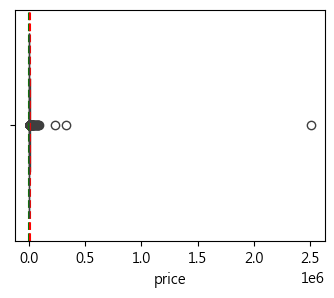

In [ ]:
Q1 = Taipei_list['price'].quantile(0.25)
Q3 = Taipei_list['price'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(4, 3))
sns.boxplot(data=Taipei_list, x='price')
plt.axvline(lower_bound, color='green', linestyle='--', label='lower_bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='upper_bound')

In [ ]:
price_12000 = Taipei_list[Taipei_list['price']<12000.0].reset_index(drop=True)

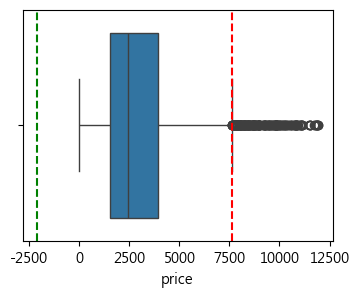

In [ ]:
Q1 = price_12000['price'].quantile(0.25)
Q3 = price_12000['price'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(4, 3))
sns.boxplot(data=price_12000, x='price')
plt.axvline(lower_bound, color='green', linestyle='--', label='lower_bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='upper_bound')

In [ ]:
price_12000.shape

(5174, 12)

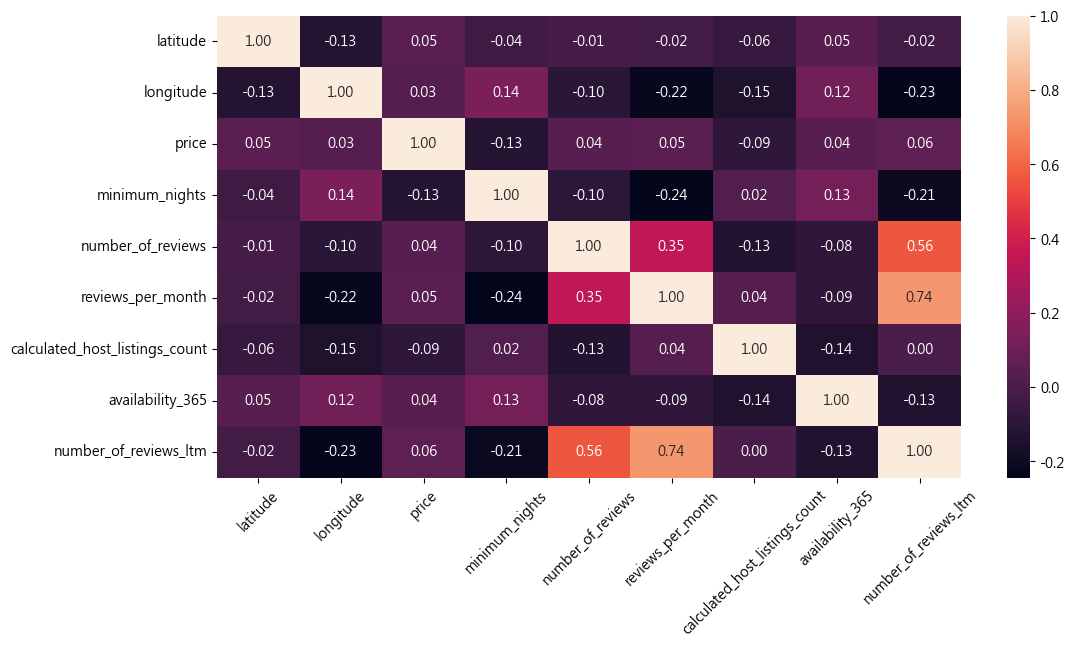

In [ ]:
price_12000_corr = price_12000.drop(columns=['host_id', 'neighbourhood', 'room_type']).corr()
plt.figure(figsize=(12, 6))
sns.heatmap(price_12000_corr, fmt='.2f', annot=True)
plt.xticks(rotation=45)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_9052\3745651075.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top30_id_counts['host_id'] = pd.Categorical(top30_id_counts['host_id'],


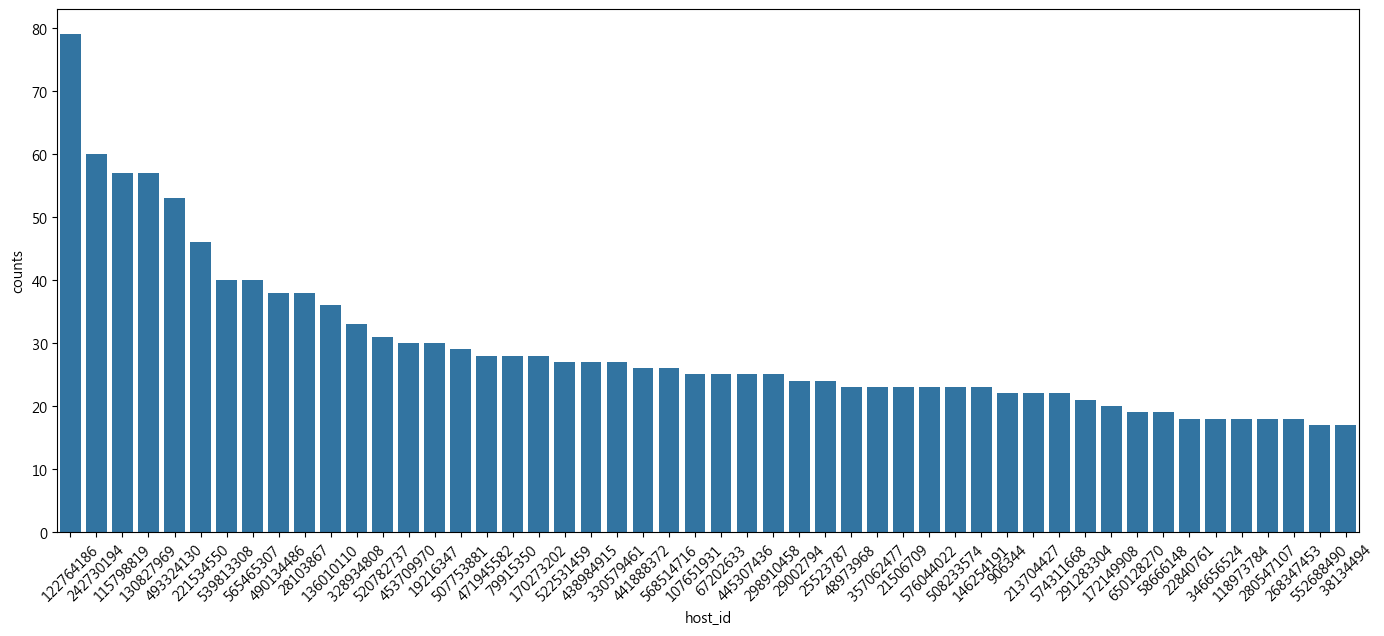

In [ ]:
id_counts = price_12000['host_id'].value_counts().reset_index()
id_counts.columns = ['host_id', 'counts']
top30_id_counts = id_counts.head(50)
top30_id_counts['host_id'] = pd.Categorical(top30_id_counts['host_id'], 
                                       categories=top30_id_counts['host_id'], 
                                       ordered=True)
plt.figure(figsize=(14, 6))
sns.barplot(data=top30_id_counts.head(50), x='host_id', y='counts')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

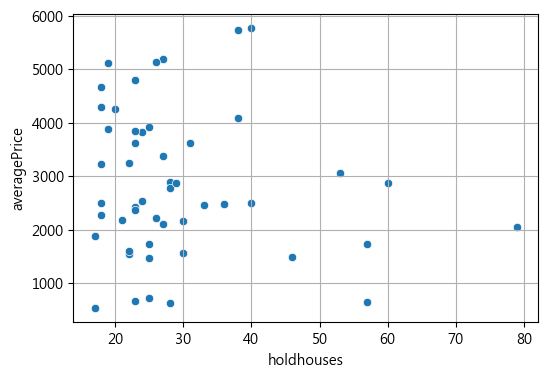

In [ ]:
top_hosts = price_12000[price_12000['host_id'].isin(top30_id_counts['host_id'])]
avg_price_per_host = top_hosts.groupby('host_id')['price'].mean().reset_index()
avg_price_per_host = avg_price_per_host.merge(top30_id_counts, on='host_id')

plt.figure(figsize=(6, 4))
sns.scatterplot(data=avg_price_per_host, x='counts', y='price')
plt.xlabel("holdhouses")
plt.ylabel("averagePrice")
plt.grid(True)
plt.show()


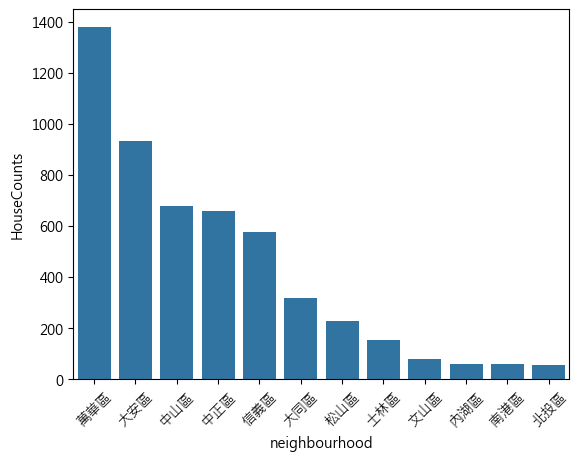

In [ ]:
sns.barplot(x=price_12000['neighbourhood'].value_counts().index, y=price_12000['neighbourhood'].value_counts().values)
plt.xticks(rotation=45)
plt.ylabel('HouseCounts')
plt.show()

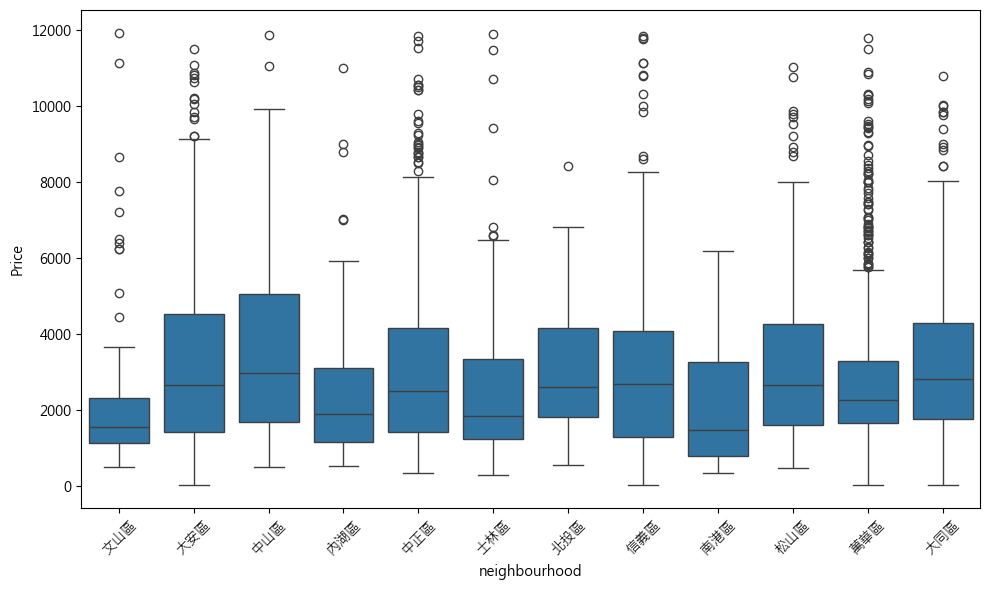

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=price_12000['neighbourhood'], y=price_12000['price'])
plt.xticks(rotation=45)
plt.ylabel('Price')
plt.tight_layout()
plt.show()

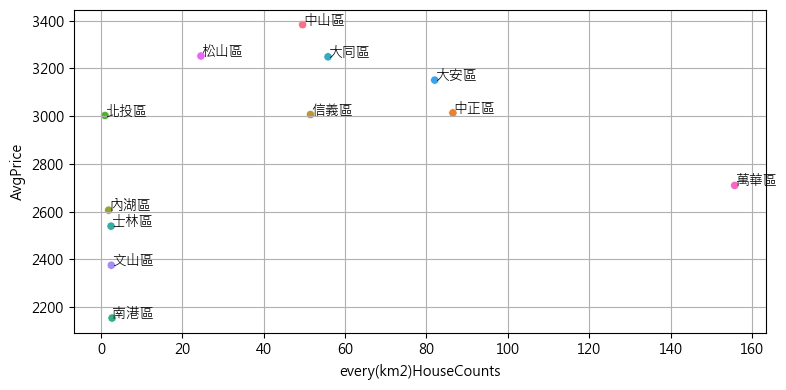

In [ ]:
neigh_stats = price_12000.groupby('neighbourhood').agg(house_count=('neighbourhood', 'count'), avg_price=('price', 'mean')).reset_index()
district_area = {'士林區': 62.3682, '北投區': 56.8216, '內湖區': 31.5787, '文山區': 31.5090, '南港區': 21.8424,
                 '中山區': 13.6821, '大安區': 11.3614, '信義區': 11.2077, '萬華區': 8.8522, '中正區': 7.6071,
                 '松山區': 9.2878, '大同區': 5.6815}

area_df = pd.DataFrame(list(district_area.items()), columns=['neighbourhood', 'area_km2'])

neigh_stats = pd.merge(neigh_stats, area_df, on='neighbourhood')

neigh_stats['density'] = neigh_stats['house_count'] / neigh_stats['area_km2']

plt.figure(figsize=(8, 4))
sns.scatterplot(data=neigh_stats, x='density', y='avg_price', hue='neighbourhood')

for i in range(neigh_stats.shape[0]):
    plt.text(neigh_stats['density'][i] + 0.1, neigh_stats['avg_price'][i], neigh_stats['neighbourhood'][i], fontsize=10)

plt.xlabel('every(km2)HouseCounts')
plt.ylabel('AvgPrice')
plt.grid(True)
plt.legend().remove()
plt.tight_layout()
plt.show()


In [ ]:
high_price = price_12000[(price_12000['price']>Q3)&(price_12000['price']<=upper_bound)].reset_index(drop=True)
mid_price = price_12000[(price_12000['price']<=Q3)&(price_12000['price']>=Q1)].reset_index(drop=True)
low_price = price_12000[(price_12000['price']<Q1)&(price_12000['price']>=lower_bound)].reset_index(drop=True)

In [ ]:
price_12000['price'] = price_12000['price'].fillna(price_12000['neighbourhood'].map(price_12000.groupby('neighbourhood')['price'].mean()))

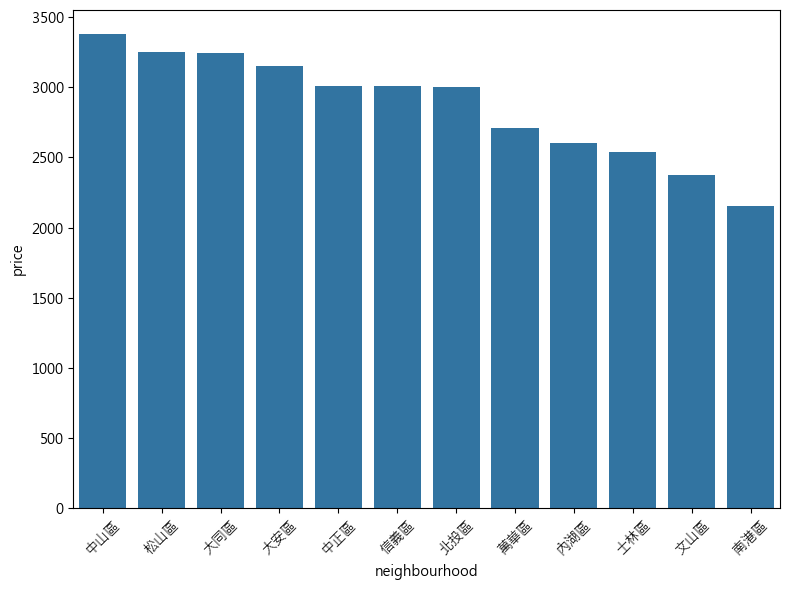

In [ ]:
average_neighbourhood_price = price_12000.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=average_neighbourhood_price, x='neighbourhood', y='price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

| 欄位名稱 | 說明 |
|---|---|
| Entire home/apt | 整間出租，適合家庭或團體 |
| Private room | 出租單間，適合單人旅遊 |
|Hotel room | 商業型旅宿（可能是飯店）|
|Shared room | 多人合住，背包客常見 |

C:\Users\USER\AppData\Local\Temp\ipykernel_9052\95460070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=price_12000, x='room_type', y='price', palette='Set2')


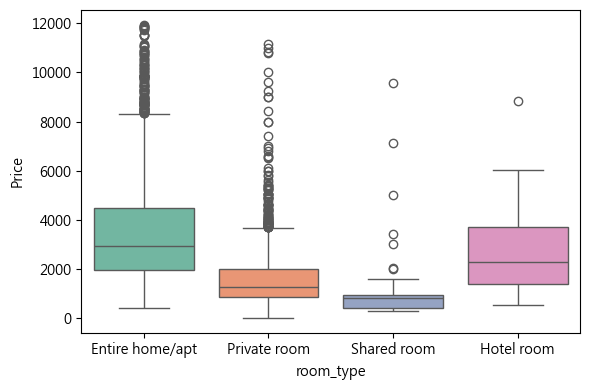

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=price_12000, x='room_type', y='price', palette='Set2')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_9052\1653261485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_counts, x='room_type', y='count', palette='Set2', ax=ax[0])
C:\Users\USER\AppData\Local\Temp\ipykernel_9052\1653261485.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_counts, x='room_type', y='proportion', palette='Set2', ax=ax[1])


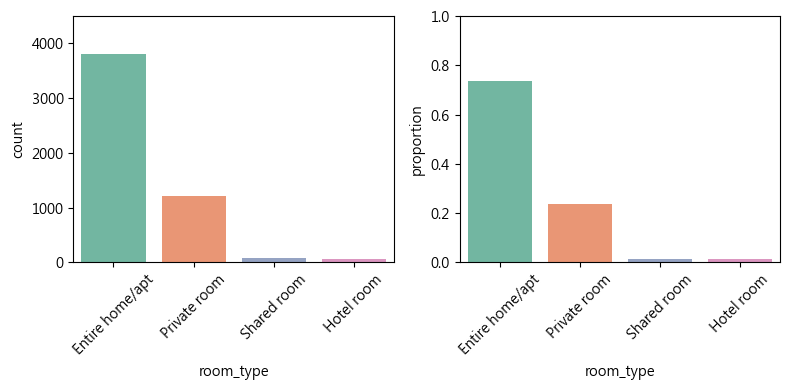

In [ ]:
room_counts = price_12000['room_type'].value_counts().reset_index()
room_counts.columns = ['room_type', 'count']
room_counts['proportion'] = room_counts['count'] / room_counts['count'].sum()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax = ax.flatten()
sns.barplot(data=room_counts, x='room_type', y='count', palette='Set2', ax=ax[0])
ax[0].set_ylim(0, 4500)
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(data=room_counts, x='room_type', y='proportion', palette='Set2', ax=ax[1])
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


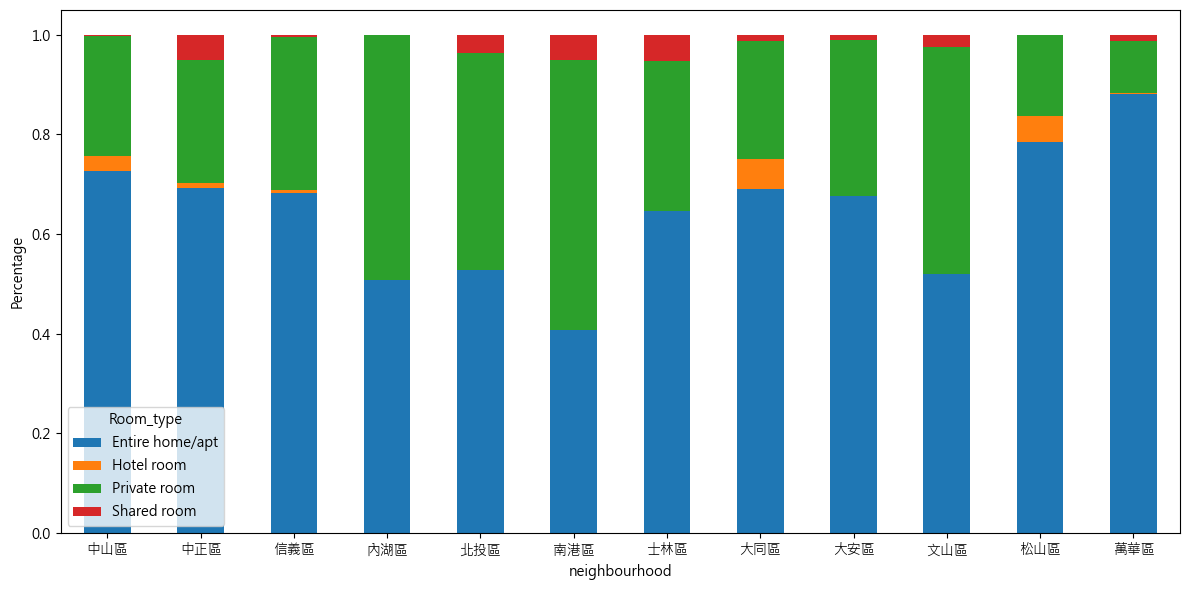

In [ ]:
room_district = pd.crosstab(price_12000['neighbourhood'], price_12000['room_type'], normalize='index')
room_district.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Room_type')
plt.tight_layout()
plt.show()
